# Retail Sales Analysis — Python Notebook
**Author:** Vijay | Data Analyst / ML Engineer
**Dataset:** `retail_sales_clean.csv` (58,799 cleaned transaction line items, 2023–2025, India)

This notebook covers:
1. Data loading & sanity checks
2. Feature engineering
3. Exploratory Data Analysis (trends, regions, categories, customers, returns, shipping)
4. Correlation analysis
5. Outlier detection
6. RFM Analysis
7. Customer segmentation with K-Means
8. Sales forecasting data preparation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/retail_sales_clean.csv', parse_dates=['Order Date', 'Ship Date'])
print(df.shape)
df.head()

(58799, 27)


,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Customer Segment,Gender,Age,City,State,Region,Product ID,Product Name,Category,Sub Category,Brand,Quantity,Unit Price,Discount,Cost Price,Sales,Profit,Profit Margin,Payment Method,Shipping Mode,Delivery Days,Returned
0,ORD-105149,2023-12-01,2023-12-04,CUST-00572,Rahul Bose,Home Office,Female,34,Hubballi,Karnataka,South,PRD-00253,Philips Home Decor Pro,Home & Furniture,Home Decor,Philips,4,"37,540.80",0.05,"26,951.16","142,655.04","34,850.40",0.24,Net Banking,Standard,3,No
1,ORD-129558,2023-10-15,2023-10-18,CUST-08497,Saanvi Mehta,Consumer,Female,59,Kochi,Kerala,South,PRD-00124,Fossil Men's Apparel Lite,Fashion,Men's Apparel,Fossil,3,"7,646.24",0.00,"5,353.41","22,938.72","6,878.49",0.30,Debit Card,Express,3,No
2,ORD-104924,2025-10-28,2025-11-06,CUST-06470,Diya Chatterjee,Consumer,Male,18,Howrah,West Bengal,East,PRD-00402,Yonex Sportswear Plus,Sports & Fitness,Sportswear,Yonex,2,"9,770.32",0.20,"7,654.14","15,632.51",324.23,0.02,Debit Card,Economy,9,No
3,ORD-127791,2024-12-09,2024-12-12,CUST-03880,Nisha Singh,Consumer,Male,18,Panaji,Goa,West,PRD-00328,Tata Snack Lite,Grocery,Snacks,Tata,3,"1,421.73",0.10,987.56,"3,838.67",875.99,0.23,Debit Card,Express,3,No
4,ORD-100161,2023-10-16,2023-10-22,CUST-06647,Unknown Customer,Consumer,Male,48,Ranchi,Jharkhand,East,PRD-00392,Cosco Fitness Equipment Plus,Sports & Fitness,Fitness Equipment,Cosco,1,"27,742.05",0.05,"19,323.38","26,354.95","7,031.57",0.27,UPI,Standard,6,No


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58799 entries, 0 to 58798
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          58799 non-null  str           
 1   Order Date        58799 non-null  datetime64[us]
 2   Ship Date         58799 non-null  datetime64[us]
 3   Customer ID       58799 non-null  str           
 4   Customer Name     58799 non-null  str           
 5   Customer Segment  58799 non-null  str           
 6   Gender            58799 non-null  str           
 7   Age               58799 non-null  int64         
 8   City              58799 non-null  str           
 9   State             58799 non-null  str           
 10  Region            58799 non-null  str           
 11  Product ID        58799 non-null  str           
 12  Product Name      58799 non-null  str           
 13  Category          58799 non-null  str           
 14  Sub Category      58799 non-null 

In [3]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Age,"58,799.00",35.00,10.32,18.00,28.00,35.00,42.00,75.00
Quantity,"58,799.00",1.98,1.13,1.00,1.00,2.00,3.00,5.00
Unit Price,"58,799.00","19,430.32","26,399.33",41.71,"1,550.83","6,980.08","28,458.48","109,181.43"
Discount,"58,799.00",0.08,0.08,0.00,0.00,0.05,0.10,0.30
Cost Price,"58,799.00","13,139.19","18,146.33",24.51,987.56,"4,760.18","19,323.38","93,372.53"
Sales,"58,799.00","35,442.62","59,373.04",35.45,"2,358.11","10,037.47","42,342.16","545,907.15"
Profit,"58,799.00","9,507.53","18,403.71","-84,727.65",548.14,"2,378.43","10,429.84","427,533.28"
Profit Margin,"58,799.00",0.27,0.11,-0.22,0.20,0.27,0.34,0.99
Delivery Days,"58,799.00",11.31,31.08,0.00,2.00,4.00,6.00,336.00


## 2. Feature Engineering

In [4]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['Order Weekday'] = df['Order Date'].dt.day_name()
df['Order YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

df['Age Band'] = pd.cut(
    df['Age'], bins=[0, 24, 34, 44, 54, 100],
    labels=['18-24', '25-34', '35-44', '45-54', '55+']
)

df['Discount Band'] = pd.cut(
    df['Discount'], bins=[-0.01, 0, 0.10, 0.20, 1.0],
    labels=['No Discount', '1-10%', '11-20%', '20%+']
)

df['Is Returned'] = (df['Returned'] == 'Yes').astype(int)
df['Net Sales'] = np.where(df['Is Returned'] == 1, 0, df['Sales'])  # returned orders contribute 0 net revenue

print('Engineered columns added.')
df[['Order YearMonth', 'Order Quarter', 'Age Band', 'Discount Band', 'Is Returned', 'Net Sales']].head()

Engineered columns added.


,Order YearMonth,Order Quarter,Age Band,Discount Band,Is Returned,Net Sales
0,2023-12,2023Q4,25-34,1-10%,0,"142,655.04"
1,2023-10,2023Q4,55+,No Discount,0,"22,938.72"
2,2025-10,2025Q4,18-24,11-20%,0,"15,632.51"
3,2024-12,2024Q4,18-24,1-10%,0,"3,838.67"
4,2023-10,2023Q4,45-54,1-10%,0,"26,354.95"


## 3. Exploratory Data Analysis
### 3.1 Monthly Sales Trend & Year-over-Year Growth

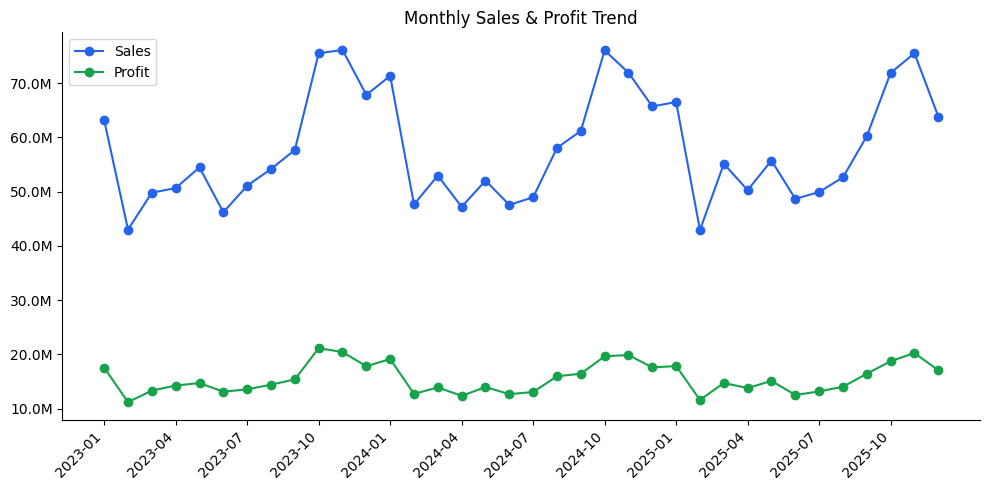

In [5]:
monthly = df.groupby('Order YearMonth').agg(
    Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique')
).reset_index()

fig, ax = plt.subplots()
ax.plot(monthly['Order YearMonth'], monthly['Sales'], marker='o', label='Sales', color='#2563eb')
ax.plot(monthly['Order YearMonth'], monthly['Profit'], marker='o', label='Profit', color='#16a34a')
ax.set_title('Monthly Sales & Profit Trend')
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly['Order YearMonth'][::3], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.savefig('../images/monthly_trend.png', dpi=120)
plt.show()

In [6]:
yearly = df.groupby('Order Year')['Sales'].sum().reset_index()
yearly['YoY Growth %'] = yearly['Sales'].pct_change() * 100
yearly

,Order Year,Sales,YoY Growth %
0,2023,"689,803,827.84",NaN
1,2024,"700,761,556.84",1.59
2,2025,"693,425,486.77",-1.05


### 3.2 Region & State Performance

In [7]:
region_perf = df.groupby('Region').agg(
    Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique')
).sort_values('Sales', ascending=False)
region_perf['Margin %'] = region_perf['Profit'] / region_perf['Sales'] * 100
region_perf

,Sales,Profit,Orders,Margin %
Region,,,,
West,"547,856,190.43","147,421,143.91",14976,26.91
South,"522,366,723.27","141,029,749.07",14279,27.00
North,"507,503,329.30","135,064,772.58",14248,26.61
East,"506,264,628.45","135,517,411.57",14215,26.77


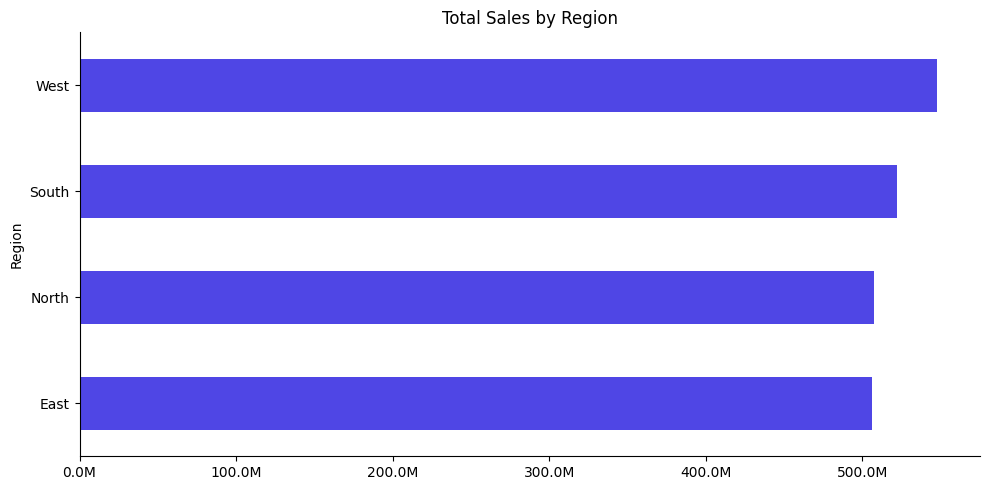

In [8]:
fig, ax = plt.subplots()
region_perf['Sales'].sort_values().plot(kind='barh', ax=ax, color='#4f46e5')
ax.set_title('Total Sales by Region')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../images/sales_by_region.png', dpi=120)
plt.show()

In [9]:
state_perf = df.groupby(['State', 'Region'])['Sales'].sum().sort_values(ascending=False).head(15)
state_perf

State          Region
Goa            West     146,603,499.03
Maharashtra    West     146,206,597.47
Karnataka      South    138,609,897.49
Haryana        North    135,893,273.63
Jharkhand      East     133,406,969.61
Gujarat        West     130,416,945.72
West Bengal    East     130,328,981.84
Kerala         South    130,072,308.46
Telangana      South    127,084,973.20
Tamil Nadu     South    126,599,544.12
Uttar Pradesh  North    124,658,716.09
Rajasthan      West     124,629,148.21
Delhi          North    123,558,981.60
Punjab         North    123,392,357.98
Odisha         East     122,779,229.07
Name: Sales, dtype: float64

### 3.3 Category & Sub-Category Analysis

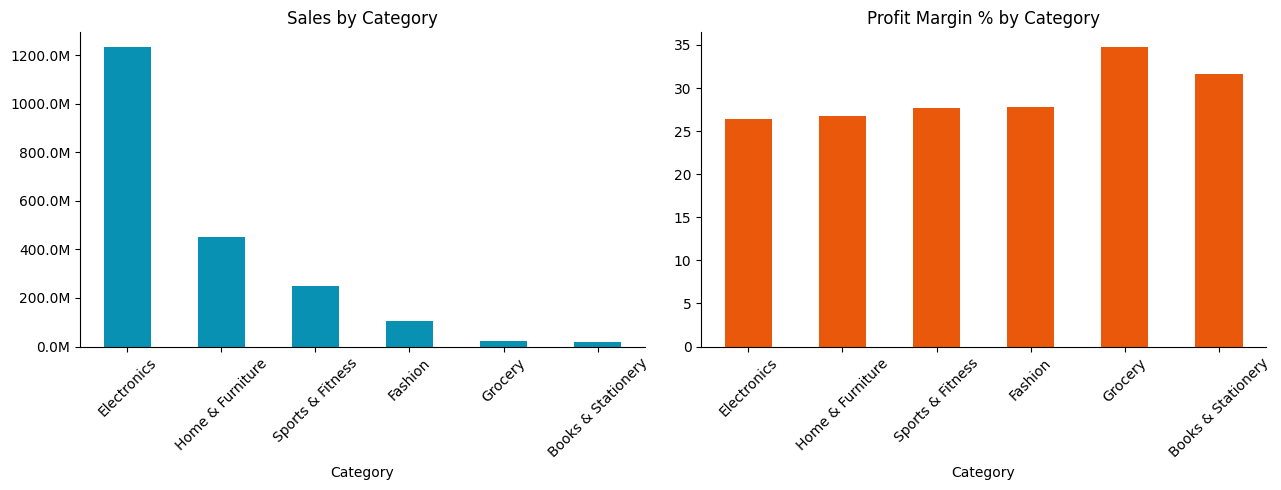

,Sales,Profit,Margin %
Category,,,
Electronics,"1,232,270,615.80","324,783,156.70",26.36
Home & Furniture,"453,027,048.34","121,396,195.42",26.80
Sports & Fitness,"250,153,909.79","69,129,383.62",27.63
Fashion,"106,566,541.41","29,677,311.61",27.85
Grocery,"24,601,378.53","8,543,913.13",34.73
Books & Stationery,"17,371,377.58","5,503,116.65",31.68


In [10]:
cat_perf = df.groupby('Category').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).sort_values('Sales', ascending=False)
cat_perf['Margin %'] = cat_perf['Profit'] / cat_perf['Sales'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat_perf['Sales'].plot(kind='bar', ax=axes[0], color='#0891b2')
axes[0].set_title('Sales by Category')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=45)

cat_perf['Margin %'].plot(kind='bar', ax=axes[1], color='#ea580c')
axes[1].set_title('Profit Margin % by Category')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../images/category_analysis.png', dpi=120)
plt.show()
cat_perf

In [11]:
subcat_perf = df.groupby(['Category', 'Sub Category'])['Sales'].sum().sort_values(ascending=False).head(15)
subcat_perf

Category          Sub Category     
Electronics       Laptops             308,705,308.29
                  Headphones          250,084,643.28
                  Cameras             226,464,698.04
                  Accessories         225,548,780.96
                  Smartphones         221,467,185.23
Home & Furniture  Kitchenware         123,887,148.78
                  Bedding              98,366,917.09
                  Home Decor           86,570,598.67
Sports & Fitness  Fitness Equipment    85,744,885.05
Home & Furniture  Lighting             79,368,880.28
                  Furniture            64,833,503.52
Sports & Fitness  Outdoor Gear         60,421,315.44
                  Cycles               53,661,107.96
                  Sportswear           50,326,601.34
Fashion           Men's Apparel        29,108,831.66
Name: Sales, dtype: float64

### 3.4 Top-Selling & Least-Performing Products

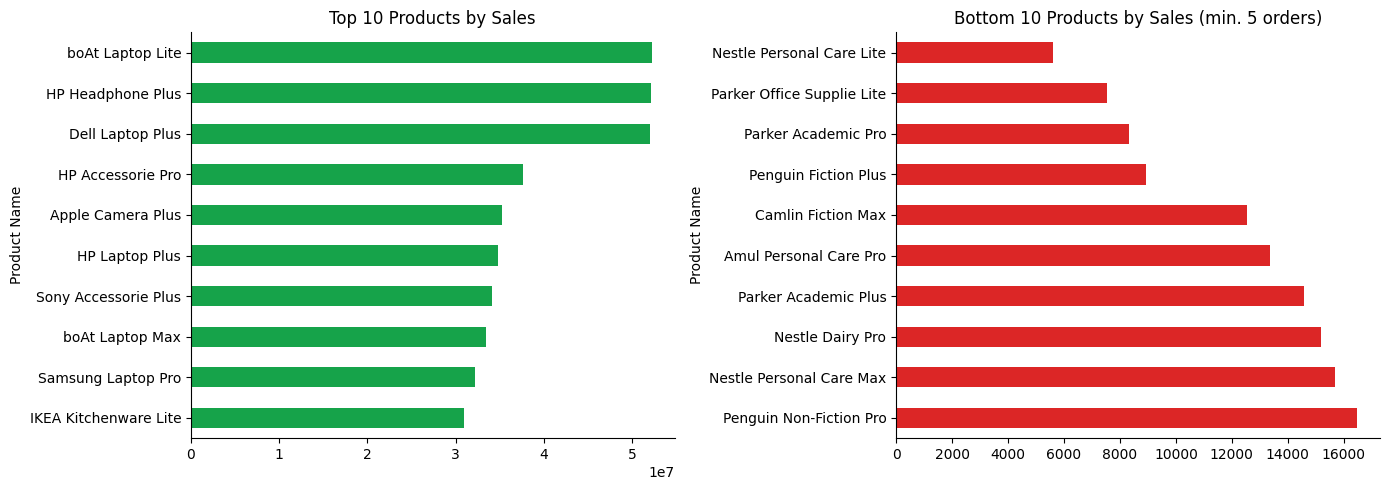

In [12]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
bottom_products = (df.groupby('Product Name')
                    .filter(lambda g: len(g) >= 5)
                    .groupby('Product Name')['Sales'].sum().sort_values().head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_products.sort_values().plot(kind='barh', ax=axes[0], color='#16a34a')
axes[0].set_title('Top 10 Products by Sales')
bottom_products.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#dc2626')
axes[1].set_title('Bottom 10 Products by Sales (min. 5 orders)')
plt.tight_layout()
plt.savefig('../images/top_bottom_products.png', dpi=120)
plt.show()

### 3.5 Customer Segmentation & Repeat Customer Analysis

In [13]:
seg_perf = df.groupby('Customer Segment').agg(
    Customers=('Customer ID', 'nunique'), Sales=('Sales', 'sum'), AOV=('Sales', 'mean')
).sort_values('Sales', ascending=False)
seg_perf

,Customers,Sales,AOV
Customer Segment,,,
Consumer,4904,"1,157,508,111.67","34,992.23"
Corporate,1744,"409,021,915.56","35,788.08"
Small Business,1255,"306,993,301.33","37,256.47"
Home Office,864,"210,467,542.89","34,782.27"


Repeat customer share: 92.2% of customers
Revenue from repeat customers: 98.8% of total revenue


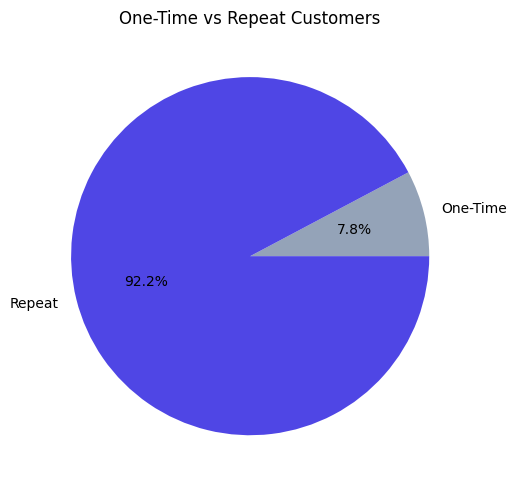

In [14]:
order_counts = df.groupby('Customer ID')['Order ID'].nunique()
repeat_share = (order_counts > 1).mean() * 100
revenue_by_cust = df.groupby('Customer ID')['Sales'].sum()
repeat_customers = order_counts[order_counts > 1].index
repeat_revenue_share = revenue_by_cust.loc[repeat_customers].sum() / revenue_by_cust.sum() * 100

print(f'Repeat customer share: {repeat_share:.1f}% of customers')
print(f'Revenue from repeat customers: {repeat_revenue_share:.1f}% of total revenue')

fig, ax = plt.subplots()
pd.Series({'One-Time': (order_counts == 1).sum(), 'Repeat': (order_counts > 1).sum()}).plot(
    kind='pie', autopct='%1.1f%%', ax=ax, colors=['#94a3b8', '#4f46e5'], ylabel=''
)
ax.set_title('One-Time vs Repeat Customers')
plt.tight_layout()
plt.savefig('../images/repeat_customers.png', dpi=120)
plt.show()

### 3.6 Payment Method & Shipping Performance

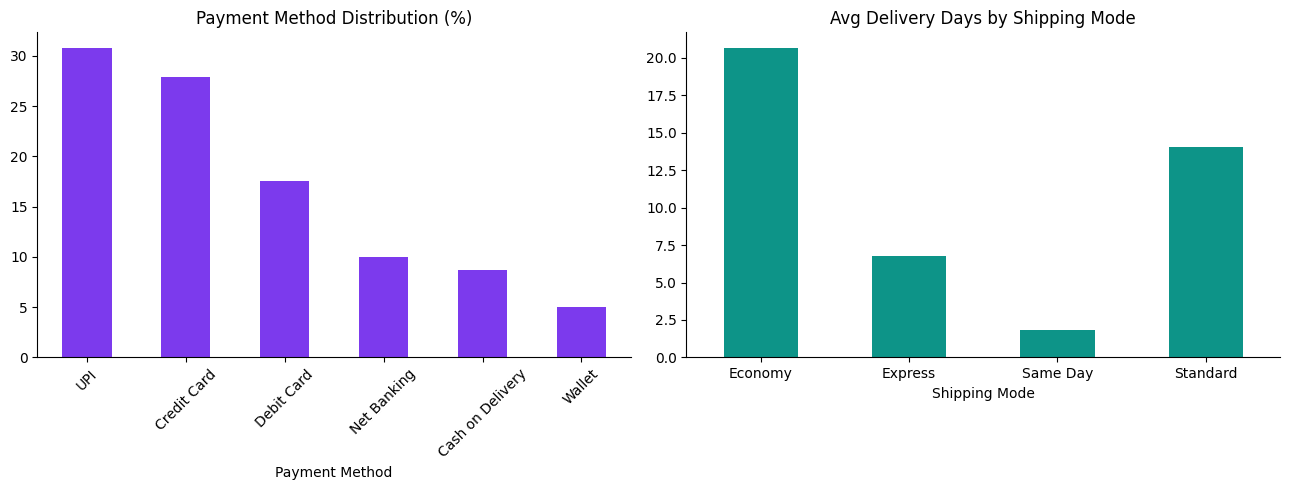

,Avg_Delivery_Days,Return_Rate
Shipping Mode,,
Economy,20.67,7.68
Express,6.79,7.48
Same Day,1.86,7.45
Standard,14.08,7.36


In [15]:
payment_dist = df['Payment Method'].value_counts(normalize=True) * 100
shipping_perf = df.groupby('Shipping Mode').agg(
    Avg_Delivery_Days=('Delivery Days', 'mean'), Return_Rate=('Is Returned', 'mean')
)
shipping_perf['Return_Rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
payment_dist.plot(kind='bar', ax=axes[0], color='#7c3aed')
axes[0].set_title('Payment Method Distribution (%)')
axes[0].tick_params(axis='x', rotation=45)

shipping_perf['Avg_Delivery_Days'].plot(kind='bar', ax=axes[1], color='#0d9488')
axes[1].set_title('Avg Delivery Days by Shipping Mode')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../images/payment_shipping.png', dpi=120)
plt.show()
shipping_perf

### 3.7 Return Analysis

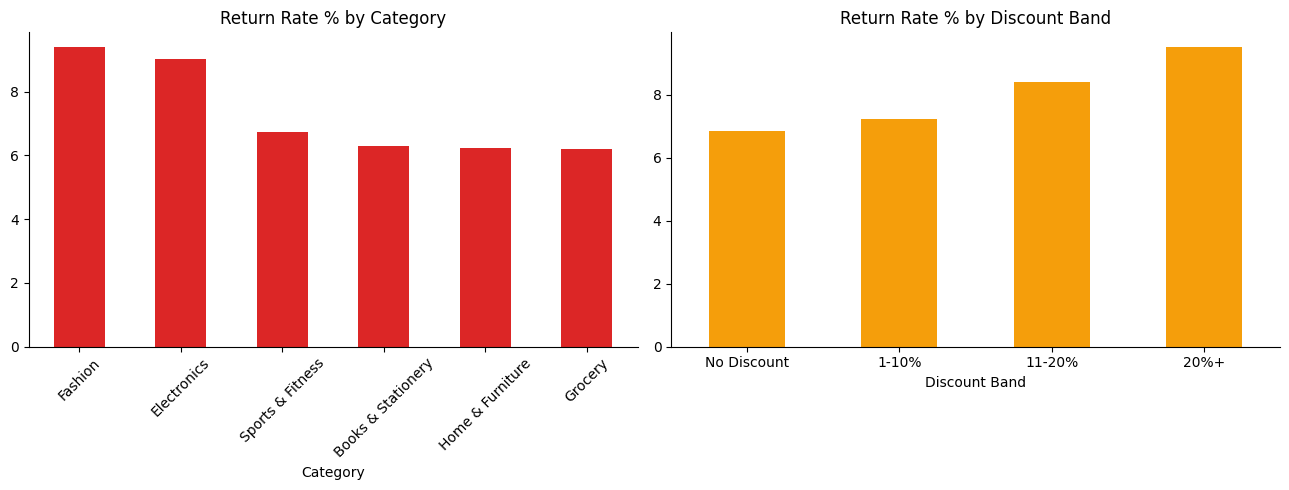

In [16]:
return_by_cat = df.groupby('Category')['Is Returned'].mean().sort_values(ascending=False) * 100
return_by_discount = df.groupby('Discount Band', observed=True)['Is Returned'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
return_by_cat.plot(kind='bar', ax=axes[0], color='#dc2626')
axes[0].set_title('Return Rate % by Category')
axes[0].tick_params(axis='x', rotation=45)

return_by_discount.plot(kind='bar', ax=axes[1], color='#f59e0b')
axes[1].set_title('Return Rate % by Discount Band')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../images/return_analysis.png', dpi=120)
plt.show()

### 3.8 Profitability & Seasonal Trends

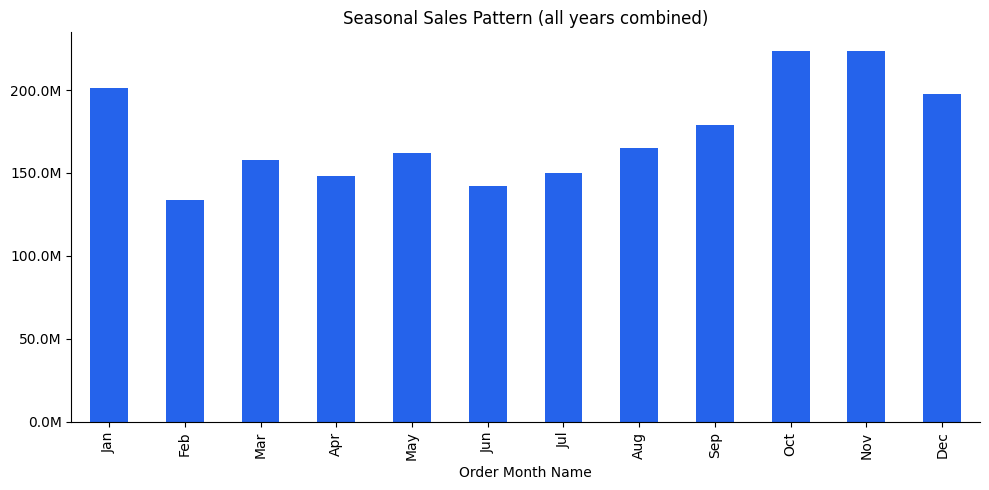

Peak months: Oct-Nov (festive season boost), Jan (New Year sales).


In [17]:
seasonal = df.groupby('Order Month Name')['Sales'].sum()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = seasonal.reindex(month_order)

fig, ax = plt.subplots()
seasonal.plot(kind='bar', ax=ax, color='#2563eb')
ax.set_title('Seasonal Sales Pattern (all years combined)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../images/seasonal_trend.png', dpi=120)
plt.show()
print('Peak months: Oct-Nov (festive season boost), Jan (New Year sales).')

## 4. Correlation Analysis

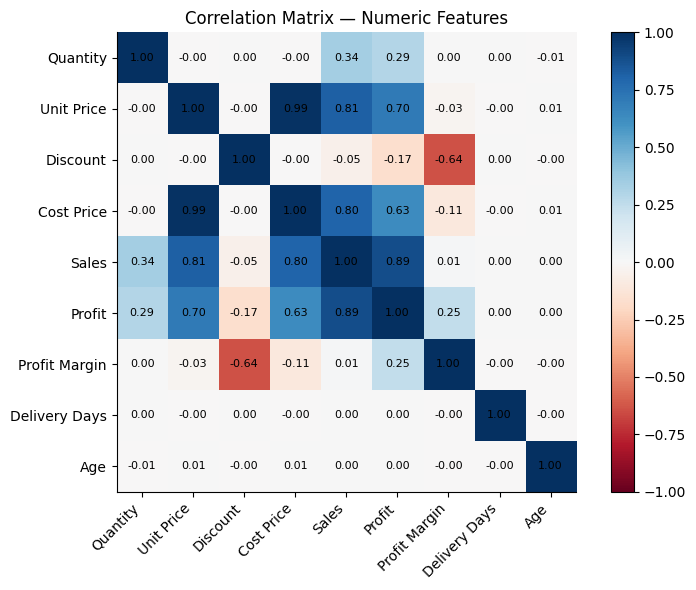

In [18]:
num_cols = ['Quantity', 'Unit Price', 'Discount', 'Cost Price', 'Sales', 'Profit',
            'Profit Margin', 'Delivery Days', 'Age']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../images/correlation_matrix.png', dpi=120)
plt.show()

**Key reads:** Discount correlates negatively with Profit Margin (as expected — heavier
discounting compresses margin). Sales and Profit move closely together since Profit is
derived from Sales. Delivery Days shows negligible linear correlation with Profit, but the
categorical return-rate-by-delivery-bucket view (SQL D7 / notebook 3.7) is a better lens
for that relationship than a linear correlation.

## 5. Outlier Detection

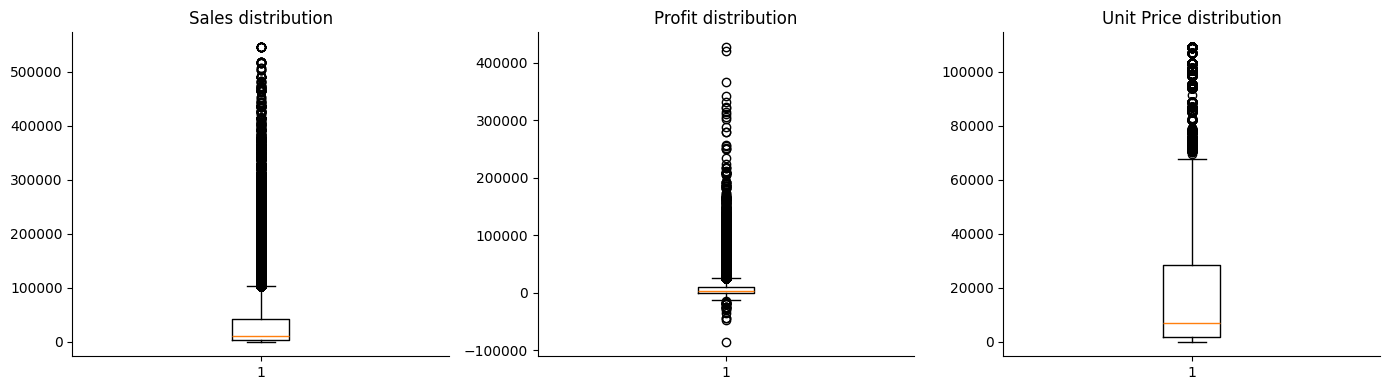

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Sales', 'Profit', 'Unit Price']):
    ax.boxplot(df[col], vert=True)
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.savefig('../images/outlier_boxplots.png', dpi=120)
plt.show()

In [20]:
# IQR-based flagging (already winsorized in cleaning; this re-validates post-clean state)
def iqr_outliers(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

sales_outliers = iqr_outliers(df['Sales'])
print(f"Remaining Sales outliers (IQR k=3): {sales_outliers.sum()} ({sales_outliers.mean()*100:.2f}%)")

# Cross-check with an unsupervised method: Isolation Forest on Sales/Profit/Quantity/Discount
iso = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
iso_features = df[['Sales', 'Profit', 'Quantity', 'Discount']]
df['Anomaly Flag'] = iso.fit_predict(iso_features)
print(f"Isolation Forest flagged anomalies: {(df['Anomaly Flag'] == -1).sum()} rows")

Remaining Sales outliers (IQR k=3): 2643 (4.49%)


Isolation Forest flagged anomalies: 583 rows


## 6. RFM Analysis (Recency, Frequency, Monetary)

In [21]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 7:
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= 5:
        return 'At Risk'
    else:
        return 'Lost / Hibernating'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
rfm['Segment'].value_counts()

Segment
Potential Loyalists    2357
Loyal Customers        2224
Champions              1744
At Risk                1335
Lost / Hibernating     1107
Name: count, dtype: int64

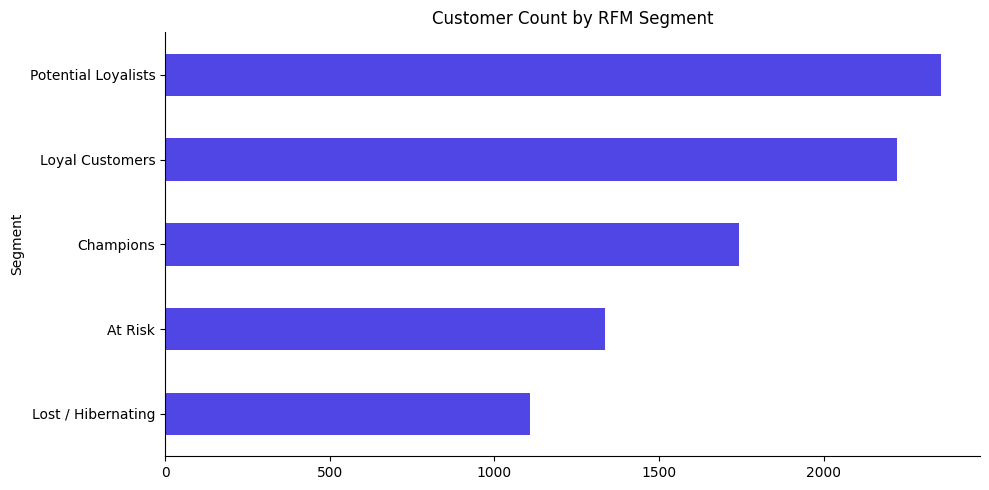

Saved RFM table -> data/customer_rfm.csv


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST-00001,162,10,"248,415.16",3,5,4,12,Loyal Customers
1,CUST-00002,332,9,"203,457.77",2,4,4,10,Loyal Customers
2,CUST-00003,46,3,"96,297.43",4,2,2,8,Potential Loyalists
3,CUST-00004,35,5,"118,560.85",5,3,3,11,Loyal Customers
4,CUST-00005,433,2,"7,824.19",1,1,1,3,Lost / Hibernating


In [22]:
fig, ax = plt.subplots()
rfm['Segment'].value_counts().sort_values().plot(kind='barh', ax=ax, color='#4f46e5')
ax.set_title('Customer Count by RFM Segment')
plt.tight_layout()
plt.savefig('../images/rfm_segments.png', dpi=120)
plt.show()

rfm.to_csv('../data/customer_rfm.csv', index=False)
print('Saved RFM table -> data/customer_rfm.csv')
rfm.head()

## 7. Customer Segmentation with K-Means

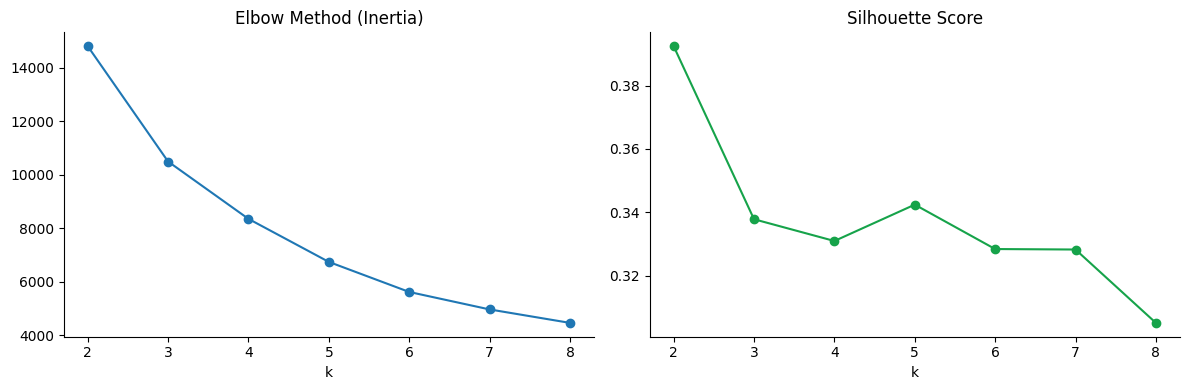

Best k by silhouette score: 2


In [23]:
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()
# log-transform Monetary/Frequency to tame skew before scaling
features['Frequency'] = np.log1p(features['Frequency'])
features['Monetary'] = np.log1p(features['Monetary'])

scaler = StandardScaler()
X = scaler.fit_transform(features)

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[1].plot(list(K_range), sil_scores, marker='o', color='#16a34a')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('../images/kmeans_selection.png', dpi=120)
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f'Best k by silhouette score: {best_k}')

In [24]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X)

cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1)
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3294,403.10,2.50,"65,065.30"
1,5473,103.20,9.00,"341,616.30"


In [25]:
fig = px.scatter_3d(
    rfm, x='Recency', y='Frequency', z='Monetary', color=rfm['Cluster'].astype(str),
    title=f'K-Means Customer Segments (k={best_k})', opacity=0.6,
    labels={'color': 'Cluster'}
)
fig.write_html('../images/kmeans_3d_clusters.html')
fig.show()

## 8. Sales Forecasting — Data Preparation

In [26]:
ts = df.groupby('Order Date')['Sales'].sum().asfreq('D').fillna(0).reset_index()
ts.columns = ['ds', 'y']  # Prophet-style naming convention for downstream forecasting tools

# Basic feature set a forecasting model (Prophet / SARIMA / XGBoost) would consume
ts['day_of_week'] = ts['ds'].dt.dayofweek
ts['month'] = ts['ds'].dt.month
ts['is_month_end'] = ts['ds'].dt.is_month_end.astype(int)
ts['rolling_7d_avg'] = ts['y'].rolling(7, min_periods=1).mean()
ts['rolling_30d_avg'] = ts['y'].rolling(30, min_periods=1).mean()

ts.to_csv('../data/daily_sales_timeseries.csv', index=False)
print(f'Daily time series prepared: {ts.shape[0]} days -> data/daily_sales_timeseries.csv')
ts.tail()

Daily time series prepared: 1096 days -> data/daily_sales_timeseries.csv


,ds,y,day_of_week,month,is_month_end,rolling_7d_avg,rolling_30d_avg
1091,2025-12-27,"1,999,905.76",5,12,0,"2,127,828.79","2,178,756.74"
1092,2025-12-28,"1,601,447.94",6,12,0,"1,989,938.44","2,090,309.50"
1093,2025-12-29,"2,242,943.77",0,12,0,"2,086,294.92","2,068,090.41"
1094,2025-12-30,"2,380,607.93",1,12,0,"2,254,176.59","2,076,911.17"
1095,2025-12-31,"1,557,083.52",2,12,1,"2,072,699.06","2,081,643.27"


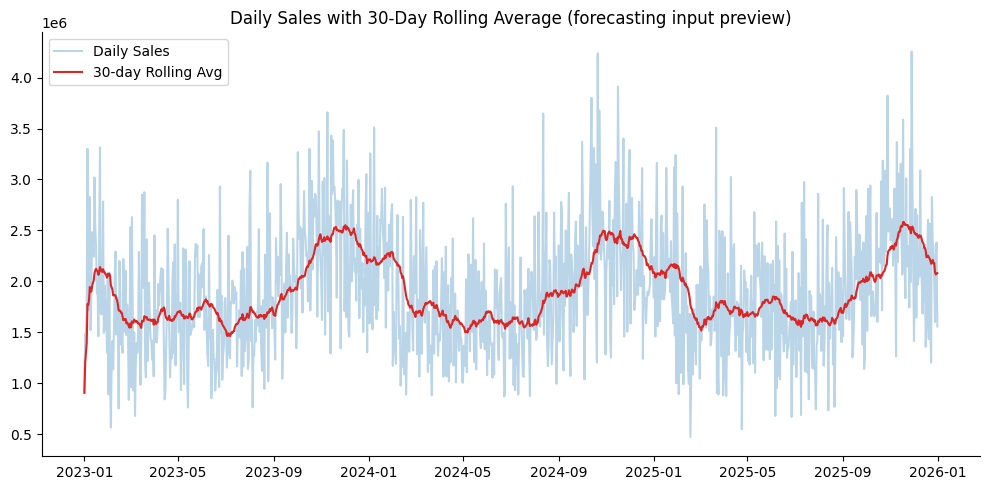

In [27]:
fig, ax = plt.subplots()
ax.plot(ts['ds'], ts['y'], alpha=0.3, label='Daily Sales')
ax.plot(ts['ds'], ts['rolling_30d_avg'], color='#dc2626', label='30-day Rolling Avg')
ax.set_title('Daily Sales with 30-Day Rolling Average (forecasting input preview)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/forecasting_prep.png', dpi=120)
plt.show()

### Notes for a next iteration
This notebook prepares clean daily/monthly series and engineered calendar features
suitable for **Prophet**, **SARIMA**, or a gradient-boosted regressor (XGBoost) with
lag features. Model *fitting* and back-tested forecasts are intentionally left as the
next milestone — this stage focuses on producing a leak-free, properly-aggregated
training table, which is usually the harder half of a forecasting project.

## 9. Summary Exports for Dashboard & Reporting

In [28]:
summary = {
    'total_sales': float(df['Sales'].sum()),
    'total_profit': float(df['Profit'].sum()),
    'total_orders': int(df['Order ID'].nunique()),
    'total_customers': int(df['Customer ID'].nunique()),
    'avg_order_value': float(df['Sales'].sum() / df['Order ID'].nunique()),
    'return_rate_pct': float(df['Is Returned'].mean() * 100),
    'overall_margin_pct': float(df['Profit'].sum() / df['Sales'].sum() * 100),
}
import json
with open('../reports/kpi_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
summary

{'total_sales': 2083990871.45,
 'total_profit': 559033077.13,
 'total_orders': 57718,
 'total_customers': 8767,
 'avg_order_value': 36106.4290420666,
 'return_rate_pct': 7.43379989455603,
 'overall_margin_pct': 26.825121203195852}